# IMPORTS Y FUNCIONES

In [1]:
from glob import glob
import torch 
import os
from torch.nn import Module
from residual_attention_unet3d import r_a_unet3d

from monai.transforms import (
    Compose,
    LoadImaged,
    ToTensord,
    EnsureChannelFirstd,
    #Spacingd
    NormalizeIntensityd,
    CropForegroundd,
    #Resized,
    ConvertToMultiChannelBasedOnBratsClassesd,
    RandRotate90d,
    RandFlipd,
    RandGaussianNoised,
    #RandSpatialCropd,
    RandCropByPosNegLabeld, 
    SpatialPadd
)
from monai.metrics import DiceMetric
from monai.data import Dataset, DataLoader

import matplotlib.pyplot as plt

import numpy as np

/home/u00p/anaconda3/envs/brats/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def definir_rutas_diccionarios():
    data = os.getcwd()
    data = os.path.dirname(data)
    data_split = os.path.join(data,'data_split')
    os.makedirs(data_split, exist_ok=True)
    data = os.path.join(data, 'data')
    data_split_train = os.path.join(data_split, 'train')
    data_split_val = os.path.join(data_split, 'val')

    mask_train = os.path.join(data_split_train,'masks')
    mask_val = os.path.join(data_split_val,'masks')
    images_train = os.path.join(data_split_train,'images')
    images_val = os.path.join(data_split_val,'images')

    flair_train = sorted(glob(os.path.join(images_train, '*_flair.nii.gz')))
    t1ce_train  = sorted(glob(os.path.join(images_train, '*_t1ce.nii.gz')))
    t1_train    = sorted(glob(os.path.join(images_train, '*_t1.nii.gz')))
    t2_train    = sorted(glob(os.path.join(images_train, '*_t2.nii.gz')))
    seg_train   = sorted(glob(os.path.join(mask_train,   '*_seg.nii.gz')))

    train_files = [
        {'image': [f, c, o, d], 'label': s}
        for f, c, o, d, s in zip(flair_train, t1ce_train, t1_train, t2_train, seg_train)
    ]

    flair_val = sorted(glob(os.path.join(images_val, '*_flair.nii.gz')))
    t1ce_val  = sorted(glob(os.path.join(images_val, '*_t1ce.nii.gz')))
    t1_val    = sorted(glob(os.path.join(images_val, '*_t1.nii.gz')))
    t2_val    = sorted(glob(os.path.join(images_val, '*_t2.nii.gz')))
    seg_val   = sorted(glob(os.path.join(mask_val,   '*_seg.nii.gz')))

    val_files = [
        {'image': [f, c, o, d], 'label': s}
        for f, c, o, d, s in zip(flair_val, t1ce_val, t1_val, t2_val, seg_val)
    ]

    print('train:', len(train_files), ' val:', len(val_files))
    if len(train_files)==0 or len(val_files)==0:
        print("Ruta equivocada!")
        raise RuntimeError("No ahy archivos")

    return train_files, val_files

In [3]:
def transformaciones():
    train_transforms = Compose(
        [
            LoadImaged(keys=['image', 'label']),
            EnsureChannelFirstd(keys='image'),
            ConvertToMultiChannelBasedOnBratsClassesd(keys='label'),
            #Spacingd(keys=['image', 'label'], pixdim=(1,1,1)),
            NormalizeIntensityd(keys='image', nonzero=True, channel_wise=True),
            CropForegroundd(keys=['image', 'label'], source_key='image'),
            #Resized(keys=['image', 'label'], spatial_size=[128,128,128], mode=('trilinear', 'nearest')),
            SpatialPadd(keys=['image', 'label'], spatial_size=[128,128,128]),
            RandCropByPosNegLabeld(keys=['image', 'label'], label_key='label',spatial_size=[128,128,128], pos=1, neg=1, num_samples=1,),
            #RandSpatialCropd(keys=['image', 'label'], roi_size=[128,128,128], random_size=False),
            RandRotate90d(keys=['image', 'label'], prob=0.5, spatial_axes=(0, 1)),
            RandFlipd(keys=['image', 'label'], prob=0.5, spatial_axis=0),
            RandFlipd(keys=['image', 'label'], prob=0.5, spatial_axis=1),
            RandFlipd(keys=['image', 'label'], prob=0.5, spatial_axis=2),
            RandGaussianNoised(keys=['image'], prob=0.2, mean=0.0, std=0.1),
            #RandModalityDropoutd(keys=['image'], prob=0.5),
            ToTensord(keys=['image', 'label'])
        ]
    )
    val_transforms = Compose(
        [
            LoadImaged(keys=['image', 'label']),
            EnsureChannelFirstd(keys='image'),
            ConvertToMultiChannelBasedOnBratsClassesd(keys='label'),
            #Spacingd(keys=['image', 'label'], pixdim=(1,1,1), mode=("bilinear", "nearest")),
            NormalizeIntensityd(keys='image', nonzero=True, channel_wise=True),
            CropForegroundd(keys=['image', 'label'], source_key='image'),
            #Resized(keys=['image', 'label'], spatial_size=[128,128,128], mode=('trilinear', 'nearest')),
            ToTensord(keys=['image', 'label'])
        ]
    )

    return train_transforms, val_transforms

In [4]:
def lotes(train_files, val_files, train_transforms, val_transforms):
    train_ds = Dataset(data=train_files, transform=train_transforms)
    train_loader = DataLoader(train_ds, batch_size=1, shuffle=True, num_workers=4, pin_memory=True)

    val_ds = Dataset(data=val_files, transform=val_transforms)
    val_loader = DataLoader(val_ds, batch_size=1, num_workers=2, pin_memory=True)

    return train_ds, train_loader, val_ds, val_loader

In [5]:
'''import torch
import numpy as np
import matplotlib.pyplot as plt

def predict_view(model, image, val_ds=False, modality='t1ce', frame='max'):

    # Modalidad a ver en el cerebro
    mod = 0

    orden_modalidades = {'flair': 0, 't1ce': 1, 't1': 2, 't2': 3}
    if modality not in orden_modalidades:
        print('Modalidad inválida, usando t1ce por defecto')
    mod = orden_modalidades.get(modality, 1)

    # --- CÁLCULO AUTOMÁTICO DEL FRAME CON MÁS TUMOR ---
    if frame == 'max':
        # La etiqueta original tiene forma [Clases, Z, Y, X]
        mask_original = image['label'] 
        # Sumamos los píxeles en las dimensiones de Clases (0), Y (2) y X (3).
        volumen_por_corte = torch.sum(mask_original, dim=(0, 2, 3))
        # Encontramos el índice con el valor máximo
        frame = int(torch.argmax(volumen_por_corte).item())
        print(f"-> Frame seleccionado automáticamente (Mayor área de tumor): Z = {frame}")

    # Predecir
    if val_ds:
        with torch.no_grad():
            img = image['image']
            mask = image['label']
            img = img.unsqueeze(0)
            mask = mask.unsqueeze(0)
            predict  = (torch.sigmoid(model(img)) > 0.5).float()
            predict = predict.detach().cpu().numpy()
    else:
        with torch.no_grad():
            img = image['image']
            mask = image['label']
            predict  = (torch.sigmoid(model(img)) > 0.5).float()
            predict = predict.detach().cpu().numpy()

    # --- EXTRACCIÓN BASADA EN CLASES OFICIALES DE BRATS (MONAI) Y CONVERSIÓN A FLOAT32 ---
    # Canal 0: TC (Tumor Core) -> Necrosis + Realzado
    # Canal 1: WT (Whole Tumor) -> Edema + Necrosis + Realzado
    # Canal 2: ET (Enhancing Tumor) -> Solo Realzado
    tc_predict = predict[0,0,frame].astype(np.float32)
    wt_predict = predict[0,1,frame].astype(np.float32)
    et_predict = predict[0,2,frame].astype(np.float32)

    tc_real = (mask[0,0,frame].cpu().numpy() if torch.is_tensor(mask) else mask[0,0,frame]).astype(np.float32)
    wt_real = (mask[0,1,frame].cpu().numpy() if torch.is_tensor(mask) else mask[0,1,frame]).astype(np.float32)
    et_real = (mask[0,2,frame].cpu().numpy() if torch.is_tensor(mask) else mask[0,2,frame]).astype(np.float32)
    
    cerebro = (img[0,mod,frame].cpu().numpy() if torch.is_tensor(img) else img[0,mod,frame]).astype(np.float32)

    # --- AISLAMIENTO DE SEGMENTOS INDIVIDUALES (Restas Lógicas) ---
    # Para graficar los colores limpios, separamos las partes restándolas:
    tumor_realzado_predict = et_predict
    necrosis_predict = np.clip(tc_predict - et_predict, 0, 1) # Lo que queda del Core al quitar el Realzado
    edema_predict = np.clip(wt_predict - tc_predict, 0, 1)    # Lo que queda de Todo al quitar el Core

    tumor_realzado_real = et_real
    necrosis_real = np.clip(tc_real - et_real, 0, 1)
    edema_real = np.clip(wt_real - tc_real, 0, 1)

    # --- PREPARACIÓN DE MÁSCARAS APILADAS Y EN COLOR ---
    stacked_pred = np.stack((tumor_realzado_predict, edema_predict, necrosis_predict), axis=-1).astype(np.float32)
    stacked_real = np.stack((tumor_realzado_real, edema_real, necrosis_real), axis=-1).astype(np.float32)

    # Máscara RGBA (A=Alpha) para transparencia al superponer
    alpha_pred = (np.clip(tumor_realzado_predict + edema_predict + necrosis_predict, 0, 1) * 0.45).astype(np.float32)
    rgba_pred = np.stack((tumor_realzado_predict, edema_predict, necrosis_predict, alpha_pred), axis=-1).astype(np.float32)

    alpha_real = (np.clip(tumor_realzado_real + edema_real + necrosis_real, 0, 1) * 0.45).astype(np.float32)
    rgba_real = np.stack((tumor_realzado_real, edema_real, necrosis_real, alpha_real), axis=-1).astype(np.float32)

    # --- VISUALIZACIÓN MATPLOTLIB ---
    fig, axes = plt.subplots(3, 4, figsize=(20, 14))
    fig.suptitle(f'Análisis de Segmentación BraTS en el Corte Z={frame} | Modalidad de fondo: {modality.upper()}', fontsize=20, fontweight='bold')
    
    # ------------------ FILA 0: PREDICCIONES ------------------
    axes[0][0].imshow(edema_predict, cmap='gray')
    axes[0][0].set_title('Predicción - Edema (Aislado)', fontsize=14)
    axes[0][0].axis('off')
    
    axes[0][1].imshow(necrosis_predict, cmap='gray')
    axes[0][1].set_title('Predicción - Necrosis/No Realzado', fontsize=14)
    axes[0][1].axis('off')
    
    axes[0][2].imshow(tumor_realzado_predict, cmap='gray')
    axes[0][2].set_title('Predicción - Tumor Realzado (ET)', fontsize=14)
    axes[0][2].axis('off')

    axes[0][3].imshow(stacked_pred)
    axes[0][3].set_title('Predicción Apilada (Color)', fontsize=14, color='darkred')
    axes[0][3].axis('off')
    
    # ------------------ FILA 1: REALIDAD (GROUND TRUTH) ------------------
    axes[1][0].imshow(edema_real, cmap='gray')
    axes[1][0].set_title('Realidad - Edema (Aislado)', fontsize=14)
    axes[1][0].axis('off')
    
    axes[1][1].imshow(necrosis_real, cmap='gray')
    axes[1][1].set_title('Realidad - Necrosis/No Realzado', fontsize=14)
    axes[1][1].axis('off')
    
    axes[1][2].imshow(tumor_realzado_real, cmap='gray')
    axes[1][2].set_title('Realidad - Tumor Realzado (ET)', fontsize=14)
    axes[1][2].axis('off')

    axes[1][3].imshow(stacked_real)
    axes[1][3].set_title('Realidad Apilada (Color)', fontsize=14, color='darkblue')
    axes[1][3].axis('off')

    # ------------------ FILA 2: CEREBRO Y SUPERPOSICIONES ------------------
    axes[2][0].imshow(cerebro, cmap='gray')
    axes[2][0].set_title('Cerebro Limpio (Sin marcas)', fontsize=14)
    axes[2][0].axis('off')

    axes[2][1].imshow(cerebro, cmap='gray')
    axes[2][1].imshow(rgba_pred) 
    axes[2][1].set_title('Cerebro + Predicción', fontsize=14, fontweight='bold')
    axes[2][1].axis('off')

    axes[2][2].imshow(cerebro, cmap='gray')
    axes[2][2].imshow(rgba_real) 
    axes[2][2].set_title('Cerebro + Realidad', fontsize=14, fontweight='bold')
    axes[2][2].axis('off')

    axes[2][3].axis('off')
    axes[2][3].text(0.1, 0.7, 'Leyenda de Segmentos:', fontsize=16, fontweight='bold')
    axes[2][3].text(0.1, 0.5, '■ Tumor Realzado (Rojo)', color='red', fontsize=15)
    axes[2][3].text(0.1, 0.3, '■ Edema Peritumoral (Verde)', color='green', fontsize=15)
    axes[2][3].text(0.1, 0.1, '■ Necrosis/No Realzado (Azul)', color='blue', fontsize=15)
    
    plt.tight_layout()
    plt.show()

    return predict'''

'import torch\nimport numpy as np\nimport matplotlib.pyplot as plt\n\ndef predict_view(model, image, val_ds=False, modality=\'t1ce\', frame=\'max\'):\n\n    # Modalidad a ver en el cerebro\n    mod = 0\n\n    orden_modalidades = {\'flair\': 0, \'t1ce\': 1, \'t1\': 2, \'t2\': 3}\n    if modality not in orden_modalidades:\n        print(\'Modalidad inválida, usando t1ce por defecto\')\n    mod = orden_modalidades.get(modality, 1)\n\n    # --- CÁLCULO AUTOMÁTICO DEL FRAME CON MÁS TUMOR ---\n    if frame == \'max\':\n        # La etiqueta original tiene forma [Clases, Z, Y, X]\n        mask_original = image[\'label\'] \n        # Sumamos los píxeles en las dimensiones de Clases (0), Y (2) y X (3).\n        volumen_por_corte = torch.sum(mask_original, dim=(0, 2, 3))\n        # Encontramos el índice con el valor máximo\n        frame = int(torch.argmax(volumen_por_corte).item())\n        print(f"-> Frame seleccionado automáticamente (Mayor área de tumor): Z = {frame}")\n\n    # Predecir\n   

### Definir el modelo

In [6]:
#Construir el modelo
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = r_a_unet3d(in_channels=4, out_channels=3, features=[32,64,128,256]).to(device)

checkpoint = torch.load('model_raunet3d.pth', map_location=device, weights_only=False)
pesos = checkpoint['model_state_dict'] if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint else checkpoint
model.load_state_dict(pesos)
model.eval()

#Lotes
train_files, val_files = definir_rutas_diccionarios()
train_transforms, val_transforms = transformaciones()
train_ds, train_loader, val_ds, val_loader = lotes(train_files, val_files, train_transforms, val_transforms)

train: 122  val: 41


### PRUEBAS DE VALIDACION DEL MODELO

In [7]:
'''dice_metric = DiceMetric(include_background=True, reduction="mean_batch")
with torch.no_grad():
    for batch in val_loader:
        imgs   = batch['image'].to(device)
        labels = batch['label'].to(device)
        preds  = (torch.sigmoid(model(imgs)) > 0.5).float()
        dice_metric(y_pred=preds, y=labels)

tc, wt, et = [float(x) for x in dice_metric.aggregate()]
dice_metric.reset()
print('===== RENDIMIENTO =====')
print(f'Tumor Core / Núcleo del Tumor (TC): {tc:.4f}  <-- (Necrosis + No Realzado + Realzado)')
print(f'Whole Tumor / Tumor Completo (WT):  {wt:.4f}  <-- (Edema + Necrosis + Realzado)')
print(f'Enhancing Tumor / Tumor Realzado (ET): {et:.4f}  <-- (Solo Realzado)')
print(f'Dice Promedio Global: {(tc + wt + et) / 3:.4f}\n')'''

'dice_metric = DiceMetric(include_background=True, reduction="mean_batch")\nwith torch.no_grad():\n    for batch in val_loader:\n        imgs   = batch[\'image\'].to(device)\n        labels = batch[\'label\'].to(device)\n        preds  = (torch.sigmoid(model(imgs)) > 0.5).float()\n        dice_metric(y_pred=preds, y=labels)\n\ntc, wt, et = [float(x) for x in dice_metric.aggregate()]\ndice_metric.reset()\nprint(\'===== RENDIMIENTO =====\')\nprint(f\'Tumor Core / Núcleo del Tumor (TC): {tc:.4f}  <-- (Necrosis + No Realzado + Realzado)\')\nprint(f\'Whole Tumor / Tumor Completo (WT):  {wt:.4f}  <-- (Edema + Necrosis + Realzado)\')\nprint(f\'Enhancing Tumor / Tumor Realzado (ET): {et:.4f}  <-- (Solo Realzado)\')\nprint(f\'Dice Promedio Global: {(tc + wt + et) / 3:.4f}\n\')'

### VISUALIZAR SEGMENTACION

In [8]:
'''predict = predict_view(model, val_ds[6], val_ds=True, frame='max', modality='t1ce')'''

"predict = predict_view(model, val_ds[6], val_ds=True, frame='max', modality='t1ce')"

# metricas por caso

In [9]:
import numpy as np, torch
from monai.inferers import sliding_window_inference
from monai.metrics import DiceMetric

CALCULAR_HD95 = False   # déjalo en False por ahora; lo prendes después si quieres bordes

dice_metric = DiceMetric(include_background=True, reduction="none", ignore_empty=True)
if CALCULAR_HD95:
    from monai.metrics import HausdorffDistanceMetric
    hd95_metric = HausdorffDistanceMetric(include_background=True, percentile=95, reduction="none")

regiones = ['TC', 'WT', 'ET']
colores  = ['#4C72B0', '#55A868', '#C44E52']

# Listas temporales que iremos llenando
dice_lista, hd95_lista, volp_lista, volr_lista = [], [], [], []

model.eval()
with torch.no_grad():
    for i, batch in enumerate(val_loader):
        img   = batch['image'].to(device)
        label = batch['label'].to(device)

        # Inferencia por ventana deslizante (firma posicional: inputs, roi, sw_batch, predictor)
        logits = sliding_window_inference(img, (128, 128, 128), 1, model, overlap=0.5)
        pred = (torch.sigmoid(logits) > 0.5).float()

        d = dice_metric(y_pred=pred, y=label).cpu().numpy().reshape(-1)   # -> [3]
        dice_lista.append(d)
        volp_lista.append(pred.sum(dim=(0, 2, 3, 4)).cpu().numpy())       # -> [3]
        volr_lista.append(label.sum(dim=(0, 2, 3, 4)).cpu().numpy())      # -> [3]

        if CALCULAR_HD95:
            h = hd95_metric(y_pred=pred, y=label).cpu().numpy().reshape(-1)
            hd95_lista.append(h)

        print(f'Caso {i+1}/{len(val_loader)}  Dice TC={d[0]:.3f} WT={d[1]:.3f} ET={d[2]:.3f}')

# --- CONVERSIÓN A NUMPY (este es el paso que antes no se ejecutaba) ---
dice_por_caso = np.asarray(dice_lista, dtype=float)   # forma [N, 3]
vol_pred      = np.asarray(volp_lista, dtype=float)
vol_real      = np.asarray(volr_lista, dtype=float)
hd95_por_caso = np.asarray(hd95_lista, dtype=float) if CALCULAR_HD95 else None
if hd95_por_caso is not None:
    hd95_por_caso[np.isinf(hd95_por_caso)] = np.nan

dice_metric.reset()

# --- VERIFICACIÓN: confirma que NO quedaron vacíos ---
print('\nSHAPES (deben ser del tipo (N, 3)):')
print('  dice_por_caso:', dice_por_caso.shape)
print('  vol_pred:', vol_pred.shape, ' vol_real:', vol_real.shape)
assert dice_por_caso.ndim == 2 and dice_por_caso.shape[1] == 3, \
    'dice_por_caso NO quedó como [N,3]. El bucle no recorrió val_loader; revisa el error de arriba.'
print('\nTodo OK. Ya puedes correr las celdas de gráficas.')

/home/u00p/anaconda3/envs/brats/lib/python3.14/site-packages/torch/utils/data/dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Caso 1/41  Dice TC=0.929 WT=0.925 ET=0.809
Caso 2/41  Dice TC=0.813 WT=0.696 ET=0.732
Caso 3/41  Dice TC=0.930 WT=0.938 ET=0.817
Caso 4/41  Dice TC=0.934 WT=0.914 ET=0.902
Caso 5/41  Dice TC=0.919 WT=0.892 ET=0.777
Caso 6/41  Dice TC=0.909 WT=0.793 ET=0.761
Caso 7/41  Dice TC=0.943 WT=0.945 ET=0.880
Caso 8/41  Dice TC=0.961 WT=0.909 ET=0.902
Caso 9/41  Dice TC=0.929 WT=0.751 ET=0.853
Caso 10/41  Dice TC=0.945 WT=0.944 ET=0.859
Caso 11/41  Dice TC=0.855 WT=0.903 ET=0.791
Caso 12/41  Dice TC=0.926 WT=0.896 ET=0.881
Caso 13/41  Dice TC=0.882 WT=0.850 ET=0.621
Caso 14/41  Dice TC=0.736 WT=0.755 ET=0.766
Caso 15/41  Dice TC=0.944 WT=0.909 ET=0.866
Caso 16/41  Dice TC=0.947 WT=0.927 ET=0.903
Caso 17/41  Dice TC=0.948 WT=0.940 ET=0.865
Caso 18/41  Dice TC=0.925 WT=0.878 ET=0.873
Caso 19/41  Dice TC=0.559 WT=0.767 ET=0.577
Caso 20/41  Dice TC=0.930 WT=0.898 ET=0.822
Caso 21/41  Dice TC=0.946 WT=0.768 ET=0.846
Caso 22/41  Dice TC=0.815 WT=0.884 ET=0.772
Caso 23/41  Dice TC=0.867 WT=0.915 ET=0.8

# grafico de barras : dice por region

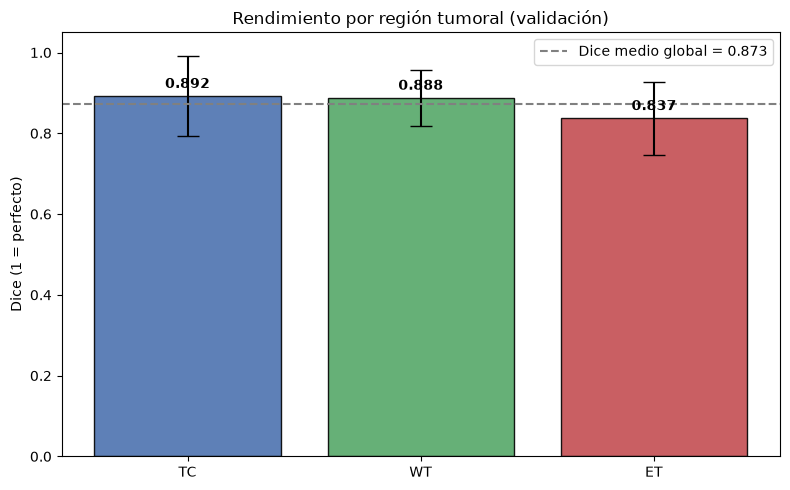

In [10]:
import matplotlib.pyplot as plt
medias = np.nanmean(dice_por_caso, axis=0)
desv   = np.nanstd(dice_por_caso, axis=0)
global_mean = np.nanmean(medias)

fig, ax = plt.subplots(figsize=(8, 5))
barras = ax.bar(regiones, medias, yerr=desv, capsize=8, color=colores, edgecolor='black', alpha=0.9)
for b, m in zip(barras, medias):
    ax.text(b.get_x() + b.get_width()/2, m + 0.02, f'{m:.3f}', ha='center', fontweight='bold')
ax.axhline(global_mean, ls='--', color='gray', label=f'Dice medio global = {global_mean:.3f}')
ax.set_ylim(0, 1.05); ax.set_ylabel('Dice (1 = perfecto)')
ax.set_title('Rendimiento por región tumoral (validación)'); ax.legend()
plt.tight_layout(); plt.show()

# distribucion entre casos

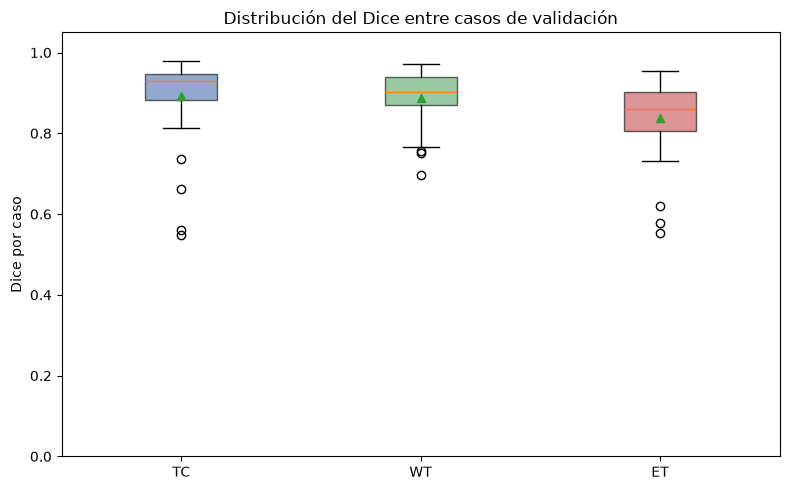

In [11]:
datos = [dice_por_caso[~np.isnan(dice_por_caso[:, j]), j] for j in range(3)]
fig, ax = plt.subplots(figsize=(8, 5))
bp = ax.boxplot(datos, patch_artist=True, showmeans=True)
ax.set_xticks(range(1, len(regiones) + 1))
ax.set_xticklabels(regiones)
for parche, c in zip(bp['boxes'], colores):
    parche.set_facecolor(c); parche.set_alpha(0.6)
ax.set_ylim(0, 1.05); ax.set_ylabel('Dice por caso')
ax.set_title('Distribución del Dice entre casos de validación')
plt.tight_layout(); plt.show()

# volumen predicho vs real

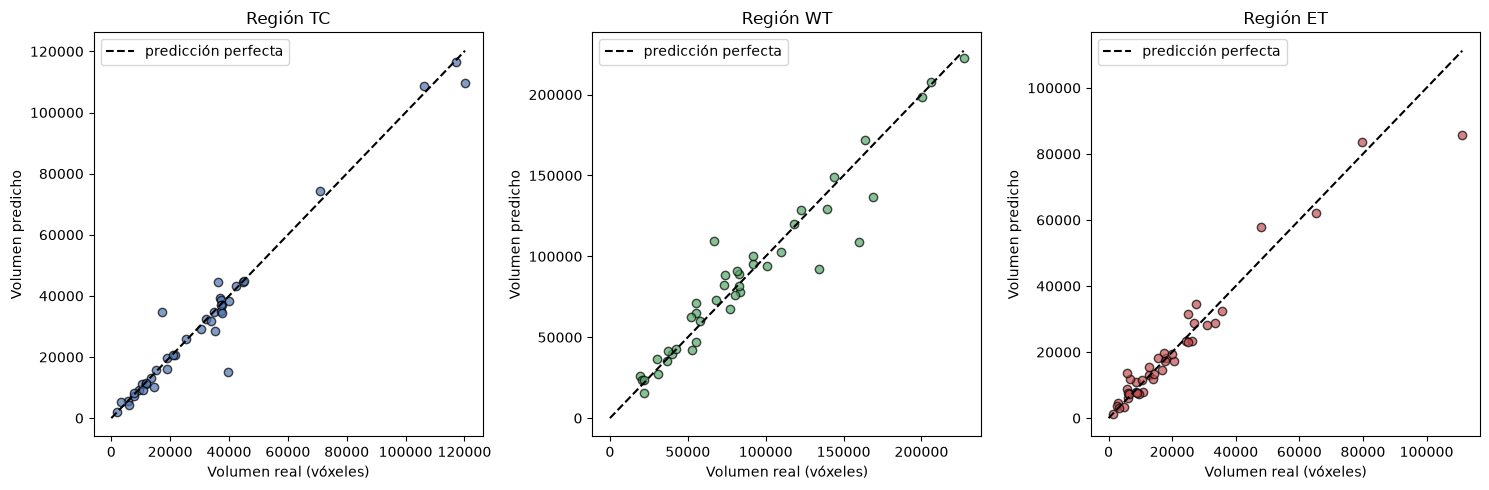

In [12]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
for j, (ax, r) in enumerate(zip(axs, regiones)):
    x, y = vol_real[:, j], vol_pred[:, j]
    ax.scatter(x, y, alpha=0.7, color=colores[j], edgecolor='black')
    lim = max(x.max(), y.max(), 1)
    ax.plot([0, lim], [0, lim], 'k--', label='predicción perfecta')
    ax.set_xlabel('Volumen real (vóxeles)'); ax.set_ylabel('Volumen predicho')
    ax.set_title(f'Región {r}'); ax.legend()
plt.tight_layout(); plt.show()